# 02 · Transfer Learning & Training: YOLO26 on Road Damage

**Computer Vision Group Project · IE School of Science & Technology**

We fine-tune the **YOLO26** detector (Ultralytics), initialised from
**COCO-pretrained weights**, on the road-damage dataset. This is transfer
learning in the sense of the course material: the convolutional backbone -
trained to recognise generic visual features on 80 COCO classes, is reused,
and the detection head is adapted to our four road-damage classes. Because
our dataset is small (300 images), starting from COCO weights is what makes
training feasible and accurate.

We train **three scales (n / s / m)** to get a real speed/accuracy comparison,
evaluate each on the held-out **test** split, and save the weights to Drive.

In [1]:
# === Colab setup: mount Drive and locate the submitted project folder ===
import sys, os, glob, subprocess

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print('Not on Colab, using local paths.')

def find_project_dir():
    pats = ['/content/drive/MyDrive/**/CompVis Group Project',
            '/content/drive/Shareddrives/**/CompVis Group Project',
            '/content/drive/MyDrive/CompVis Group Project']
    for p in pats:
        hits = glob.glob(p, recursive=True)
        if hits:
            return hits[0]
    return os.path.abspath('..')  # local fallback (notebooks/ -> project root)

PROJECT_DIR = find_project_dir()
print('PROJECT_DIR =', PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)


Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/CompVis Group Project


## 0. Reproducibility note: embedded project source

For reproducibility in Google Colab, this notebook writes its helper modules to `/content/src/` at runtime. This keeps the submitted notebook self-contained: the teacher only needs the project folder and the `Data/` directory included with this submission.

In [2]:
# Create the package directory and make it importable.
import os, sys
os.makedirs('/content/src', exist_ok=True)
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

In [3]:
%%writefile /content/src/config.py
"""
Central configuration for the Road Damage Detection project.

Everything that the notebooks and the other modules need to agree on lives here:
the class taxonomy, the colour palette used for plotting, the default training
hyper-parameters and the weights of the rule-based severity model. Keeping these
in one place means a single edit propagates to the EDA, training, inference and
demo code without any duplication.
"""
from __future__ import annotations

import glob
import os
from dataclasses import dataclass, field
from pathlib import Path

# --------------------------------------------------------------------------- #
# Class taxonomy
# --------------------------------------------------------------------------- #
# The four RDD2022 damage categories we keep. The order defines the integer
# class id used in the YOLO label files (D00 -> 0, D10 -> 1, D20 -> 2, D40 -> 3).
CLASS_IDS: dict[str, int] = {
    "D00": 0,  # longitudinal crack  (runs along the driving direction)
    "D10": 1,  # transverse crack    (runs across the road)
    "D20": 2,  # alligator crack     (interconnected / fatigue cracking)
    "D40": 3,  # pothole
}
ID_TO_CLASS: dict[int, str] = {v: k for k, v in CLASS_IDS.items()}

# Human-readable names used in plots, the report and the demo UI.
CLASS_NAMES: dict[str, str] = {
    "D00": "Longitudinal crack",
    "D10": "Transverse crack",
    "D20": "Alligator crack",
    "D40": "Pothole",
}
# Ordered list of short codes, indexed by class id. This is what goes into the
# `names:` field of the Ultralytics data.yaml.
YOLO_NAMES: list[str] = [ID_TO_CLASS[i] for i in range(len(ID_TO_CLASS))]

# Distinct, colour-blind friendly RGB colours per class (for matplotlib / cv2).
CLASS_COLORS: dict[str, tuple[int, int, int]] = {
    "D00": (31, 119, 180),   # blue
    "D10": (255, 127, 14),   # orange
    "D20": (148, 103, 189),  # purple
    "D40": (214, 39, 40),    # red
}

# Severity is drawn with a fixed traffic-light palette so it reads instantly.
SEVERITY_COLORS: dict[str, tuple[int, int, int]] = {
    "Low": (44, 160, 44),     # green
    "Medium": (255, 193, 7),  # amber
    "High": (214, 39, 40),    # red
}
SEVERITY_LEVELS: list[str] = ["Low", "Medium", "High"]

# --------------------------------------------------------------------------- #
# Severity model parameters
# --------------------------------------------------------------------------- #
# The severity score has no ground truth in RDD2022, so it is an engineered,
# fully transparent heuristic. Each class carries a base severity that reflects
# its structural meaning, and the geometry of the box (size / extent) scales it.
# These numbers are documented and justified in report/REPORT.md and can be
# tuned in one place.
SEVERITY_BASE: dict[str, float] = {
    "D00": 0.25,  # a single longitudinal crack is usually minor
    "D10": 0.30,  # transverse cracks slightly worse (water ingress, edges)
    "D20": 0.55,  # alligator cracking signals fatigue / sub-base failure
    "D40": 0.60,  # potholes are an immediate hazard
}
# Thresholds that turn the continuous 0-1 score into a Low/Medium/High label.
SEVERITY_THRESHOLDS: tuple[float, float] = (0.34, 0.67)

# --------------------------------------------------------------------------- #
# Training defaults (reported verbatim in the notebook and the report)
# --------------------------------------------------------------------------- #
@dataclass
class TrainConfig:
    model_scales: list[str] = field(default_factory=lambda: ["n", "s", "m"])
    epochs: int = 100
    patience: int = 20          # early-stopping patience
    imgsz: int = 512            # native resolution of the RDD China-Drone tiles
    batch: int = 16
    optimizer: str = "AdamW"
    lr0: float = 1e-3           # initial learning rate
    lrf: float = 1e-2           # final lr factor (cosine schedule -> lr0*lrf)
    cos_lr: bool = True         # cosine learning-rate scheduler
    weight_decay: float = 5e-4
    warmup_epochs: float = 3.0
    seed: int = 42
    amp: bool = True            # automatic mixed precision
    # Data augmentation (Ultralytics keys). Tuned for small, top-down road tiles:
    # heavy mosaic, modest colour jitter, no vertical flip (gravity matters less
    # from a drone, but we keep it off to stay faithful to capture geometry).
    hsv_h: float = 0.015
    hsv_s: float = 0.5
    hsv_v: float = 0.4
    fliplr: float = 0.5
    flipud: float = 0.0
    mosaic: float = 1.0
    scale: float = 0.5
    translate: float = 0.1
    close_mosaic: int = 10      # disable mosaic for the last N epochs


TRAIN = TrainConfig()

# --------------------------------------------------------------------------- #
# Data-split configuration
# --------------------------------------------------------------------------- #
SPLIT_RATIOS: tuple[float, float, float] = (0.70, 0.20, 0.10)  # train / val / test
SPLIT_SEED: int = 42


# --------------------------------------------------------------------------- #
# Path discovery
# --------------------------------------------------------------------------- #
def find_project_dir() -> Path:
    """Locate the project root both locally and inside Google Colab.

    On Colab the folder lives somewhere under a mounted Drive; we glob for it so
    the notebooks do not hard-code a brittle absolute path. Locally we fall back
    to the parent of this file's `src/` directory.
    """
    patterns = [
        "/content/drive/MyDrive/**/CompVis Group Project",
        "/content/drive/Shareddrives/**/CompVis Group Project",
        "/content/drive/MyDrive/CompVis Group Project",
    ]
    for pattern in patterns:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return Path(hits[0])
    # Local fallback: src/ -> project root
    return Path(__file__).resolve().parent.parent


def get_paths(project_dir: str | os.PathLike | None = None) -> dict[str, Path]:
    """Return the canonical set of paths used across the project."""
    root = Path(project_dir) if project_dir else find_project_dir()
    return {
        "root": root,
        "raw_images": root / "Data" / "images",
        "raw_annotations": root / "Data" / "annotations" / "xmls",
        "yolo_dataset": root / "outputs" / "yolo_dataset",
        "data_yaml": root / "outputs" / "yolo_dataset" / "data.yaml",
        "models": root / "models",
        "outputs": root / "outputs",
        "figures": root / "figures",
        "report": root / "report",
    }


Writing /content/src/config.py


In [4]:
%%writefile /content/src/data_prep.py
"""
Dataset preparation: Pascal VOC (XML) -> Ultralytics YOLO format.

The RDD2022 China-Drone subset ships as 300 JPEGs plus one Pascal VOC XML per
image. Ultralytics YOLO expects normalised `class cx cy w h` text labels and a
`data.yaml` describing the splits. This module performs that conversion, builds
a reproducible, stratified train/val/test split, and writes the YOLO directory
tree. All functions are pure and seeded so a grader can reproduce the exact
split byte-for-byte.
"""
from __future__ import annotations

import random
import shutil
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

from . import config


@dataclass
class BBox:
    """A single object: class code plus pixel corner coordinates."""
    cls: str
    xmin: float
    ymin: float
    xmax: float
    ymax: float

    @property
    def width(self) -> float:
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        return self.ymax - self.ymin

    @property
    def area(self) -> float:
        return max(0.0, self.width) * max(0.0, self.height)


@dataclass
class Annotation:
    """All objects in one image plus the image size."""
    filename: str
    width: int
    height: int
    boxes: list[BBox]


# --------------------------------------------------------------------------- #
# Parsing
# --------------------------------------------------------------------------- #
def parse_voc_xml(xml_path: str | Path) -> Annotation:
    """Parse one Pascal VOC XML file into an `Annotation`.

    Objects whose class is not part of `config.CLASS_IDS` are silently skipped,
    and boxes are clamped to the image bounds to guard against the occasional
    off-by-one coordinate found in RDD2022.
    """
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    width = int(float(size.findtext("width")))
    height = int(float(size.findtext("height")))

    boxes: list[BBox] = []
    for obj in root.findall("object"):
        cls = (obj.findtext("name") or "").strip()
        if cls not in config.CLASS_IDS:
            continue
        bb = obj.find("bndbox")
        xmin = max(0.0, float(bb.findtext("xmin")))
        ymin = max(0.0, float(bb.findtext("ymin")))
        xmax = min(float(width), float(bb.findtext("xmax")))
        ymax = min(float(height), float(bb.findtext("ymax")))
        if xmax <= xmin or ymax <= ymin:
            continue  # degenerate box
        boxes.append(BBox(cls, xmin, ymin, xmax, ymax))
    return Annotation(
        filename=root.findtext("filename") or Path(xml_path).stem + ".jpg",
        width=width,
        height=height,
        boxes=boxes,
    )


def load_all_annotations(annotations_dir: str | Path) -> list[Annotation]:
    """Parse every XML in a directory, sorted for determinism."""
    annotations_dir = Path(annotations_dir)
    xmls = sorted(annotations_dir.glob("*.xml"))
    return [parse_voc_xml(p) for p in xmls]


# --------------------------------------------------------------------------- #
# VOC box -> YOLO line
# --------------------------------------------------------------------------- #
def voc_to_yolo_line(box: BBox, img_w: int, img_h: int) -> str:
    """Convert one VOC box to a normalised YOLO label line."""
    cx = (box.xmin + box.xmax) / 2.0 / img_w
    cy = (box.ymin + box.ymax) / 2.0 / img_h
    w = box.width / img_w
    h = box.height / img_h
    cls_id = config.CLASS_IDS[box.cls]
    return f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"


# --------------------------------------------------------------------------- #
# Stratified split
# --------------------------------------------------------------------------- #
def stratified_split(
    annotations: list[Annotation],
    ratios: tuple[float, float, float] = config.SPLIT_RATIOS,
    seed: int = config.SPLIT_SEED,
) -> dict[str, list[Annotation]]:
    """Split images into train/val/test, balancing the rarest class.

    With only 300 images and a heavy class imbalance (potholes are scarce), a
    naive random split can leave a split with zero potholes. We therefore order
    images by their rarest contained class and deal them round-robin into the
    splits according to the target ratios, which keeps every class present in
    every split while remaining fully deterministic.
    """
    rng = random.Random(seed)

    # Global class frequency -> "rarity" ranking (rarer = smaller count).
    class_freq: Counter[str] = Counter()
    for ann in annotations:
        for b in ann.boxes:
            class_freq[b.cls] += 1
    rarity = {c: i for i, c in enumerate(sorted(class_freq, key=class_freq.get))}

    def sort_key(ann: Annotation) -> tuple[int, float]:
        present = {b.cls for b in ann.boxes}
        rarest = min((rarity[c] for c in present), default=len(rarity))
        return (rarest, rng.random())

    ordered = sorted(annotations, key=sort_key)

    splits: dict[str, list[Annotation]] = {"train": [], "val": [], "test": []}
    names = ["train", "val", "test"]
    # Deal each image to whichever split is furthest below its target share.
    targets = dict(zip(names, ratios))
    for ann in ordered:
        total = sum(len(splits[n]) for n in names) or 1
        deficits = {n: targets[n] - len(splits[n]) / total for n in names}
        chosen = max(names, key=lambda n: deficits[n])
        splits[chosen].append(ann)
    return splits


# --------------------------------------------------------------------------- #
# Writing the YOLO dataset
# --------------------------------------------------------------------------- #
def build_yolo_dataset(
    images_dir: str | Path,
    annotations_dir: str | Path,
    out_dir: str | Path,
    ratios: tuple[float, float, float] = config.SPLIT_RATIOS,
    seed: int = config.SPLIT_SEED,
    copy_images: bool = True,
) -> dict:
    """Convert the whole VOC dataset to a YOLO directory tree + data.yaml.

    Returns a small summary dict (per-split image and box counts) that the EDA
    notebook prints so the split is auditable.
    """
    images_dir = Path(images_dir)
    out_dir = Path(out_dir)

    annotations = load_all_annotations(annotations_dir)
    splits = stratified_split(annotations, ratios, seed)

    summary: dict = {"per_split": {}, "class_per_split": defaultdict(dict)}

    for split_name, anns in splits.items():
        img_out = out_dir / "images" / split_name
        lbl_out = out_dir / "labels" / split_name
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        box_count = 0
        cls_counter: Counter[str] = Counter()
        for ann in anns:
            stem = Path(ann.filename).stem
            src_img = images_dir / ann.filename
            if not src_img.exists():  # tolerate .JPG/.jpg or missing files
                alt = list(images_dir.glob(stem + ".*"))
                if not alt:
                    continue
                src_img = alt[0]
            if copy_images:
                shutil.copy2(src_img, img_out / src_img.name)

            lines = [voc_to_yolo_line(b, ann.width, ann.height) for b in ann.boxes]
            (lbl_out / f"{stem}.txt").write_text("\n".join(lines))
            box_count += len(ann.boxes)
            for b in ann.boxes:
                cls_counter[b.cls] += 1

        summary["per_split"][split_name] = {"images": len(anns), "boxes": box_count}
        summary["class_per_split"][split_name] = dict(cls_counter)

    write_data_yaml(out_dir)
    summary["class_per_split"] = dict(summary["class_per_split"])
    return summary


def write_data_yaml(out_dir: str | Path) -> Path:
    """Write the Ultralytics data.yaml pointing at the three splits."""
    out_dir = Path(out_dir)
    names_block = "\n".join(f"  {i}: {n}" for i, n in enumerate(config.YOLO_NAMES))
    yaml_text = (
        f"# Auto-generated by src/data_prep.py - Road Damage Detection (RDD2022)\n"
        f"path: {out_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"test: images/test\n"
        f"nc: {len(config.YOLO_NAMES)}\n"
        f"names:\n{names_block}\n"
    )
    yaml_path = out_dir / "data.yaml"
    yaml_path.write_text(yaml_text)
    return yaml_path


def dataset_class_distribution(annotations: list[Annotation]) -> Counter:
    """Total box count per class across a list of annotations (for EDA)."""
    counter: Counter[str] = Counter()
    for ann in annotations:
        for b in ann.boxes:
            counter[b.cls] += 1
    return counter


Writing /content/src/data_prep.py


In [5]:
%%writefile /content/src/train.py
"""
Transfer-learning training helpers built on Ultralytics.

These functions wrap `YOLO(...).train(...)` so the notebook can train several
model scales with one loop while keeping every reported hyper-parameter in
`config.TrainConfig`. The only non-obvious piece is `resolve_pretrained`, which
picks a YOLO26 COCO checkpoint when the installed Ultralytics exposes it and
transparently falls back to YOLOv8 otherwise, so the notebook runs regardless of
the exact library version a grader has.
"""
from __future__ import annotations

from pathlib import Path

from . import config


def resolve_pretrained(scale: str, task: str = "detect") -> str:
    """Return a COCO-pretrained checkpoint name for the given scale.

    Tries the YOLO26 family first (the project's chosen model) and falls back to
    YOLOv8 if those weights cannot be resolved by the installed Ultralytics.
    Transfer learning = we start from these COCO weights, not from scratch.
    """
    suffix = "-obb" if task == "obb" else ""
    candidates = [f"yolo26{scale}{suffix}.pt", f"yolov8{scale}{suffix}.pt"]
    from ultralytics import YOLO  # local import keeps module importable offline

    for name in candidates:
        try:
            YOLO(name)  # downloads/validates the checkpoint
            return name
        except Exception:
            continue
    # Last resort: let Ultralytics raise its own clear error on the v8 name.
    return candidates[-1]


def train_one(
    scale: str,
    data_yaml: str | Path,
    project_dir: str | Path,
    cfg: config.TrainConfig = config.TRAIN,
    run_name: str | None = None,
):
    """Fine-tune one YOLO model scale and return (trained_model, results)."""
    from ultralytics import YOLO

    weights = resolve_pretrained(scale)
    model = YOLO(weights)
    run_name = run_name or f"road_damage_{Path(weights).stem}"

    results = model.train(
        data=str(data_yaml),
        epochs=cfg.epochs,
        patience=cfg.patience,
        imgsz=cfg.imgsz,
        batch=cfg.batch,
        optimizer=cfg.optimizer,
        lr0=cfg.lr0,
        lrf=cfg.lrf,
        cos_lr=cfg.cos_lr,
        weight_decay=cfg.weight_decay,
        warmup_epochs=cfg.warmup_epochs,
        seed=cfg.seed,
        amp=cfg.amp,
        hsv_h=cfg.hsv_h, hsv_s=cfg.hsv_s, hsv_v=cfg.hsv_v,
        fliplr=cfg.fliplr, flipud=cfg.flipud,
        mosaic=cfg.mosaic, scale=cfg.scale, translate=cfg.translate,
        close_mosaic=cfg.close_mosaic,
        project=str(Path(project_dir) / "runs"),
        name=run_name,
        exist_ok=True,
        verbose=True,
    )
    return model, results


def count_parameters(model) -> int:
    """Total number of parameters of an Ultralytics model."""
    return sum(p.numel() for p in model.model.parameters())


Writing /content/src/train.py


In [6]:
%%writefile /content/src/evaluation.py
"""
Evaluation utilities: turn Ultralytics validation results into the metrics,
tables and plots the project specification asks for (mAP50, mAP50-95, precision,
recall, F1, per-class AP, parameter counts, training curves, model comparison).

These helpers are thin wrappers so the training notebook stays readable: the
heavy lifting (mAP computation, confusion matrix) is done by Ultralytics; here
we just extract, tabulate and plot.
"""
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

from . import config


def metrics_from_results(results, model_name: str, n_params: int | None = None) -> dict:
    """Extract the headline metrics from an Ultralytics `val()` results object."""
    box = results.box
    precision = float(np.mean(box.p)) if len(box.p) else float("nan")
    recall = float(np.mean(box.r)) if len(box.r) else float("nan")
    f1 = (2 * precision * recall / (precision + recall)
          if precision + recall > 0 else float("nan"))
    return {
        "model": model_name,
        "params(M)": round(n_params / 1e6, 2) if n_params else None,
        "mAP50": round(float(box.map50), 4),
        "mAP50-95": round(float(box.map), 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "F1": round(f1, 4),
    }


def per_class_table(results) -> pd.DataFrame:
    """Per-class AP50 / AP50-95 table from a `val()` result."""
    box = results.box
    rows = []
    for i, c in enumerate(box.ap_class_index):
        code = config.ID_TO_CLASS.get(int(c), str(c))
        rows.append({
            "class": code,
            "name": config.CLASS_NAMES.get(code, code),
            "AP50": round(float(box.ap50[i]), 4),
            "AP50-95": round(float(box.ap[i]), 4),
            "precision": round(float(box.p[i]), 4),
            "recall": round(float(box.r[i]), 4),
        })
    return pd.DataFrame(rows)


def comparison_table(metric_dicts: list[dict]) -> pd.DataFrame:
    """Stack the per-model metric dicts into a single comparison DataFrame."""
    return pd.DataFrame(metric_dicts).set_index("model")


# --------------------------------------------------------------------------- #
# Plots
# --------------------------------------------------------------------------- #
def plot_training_curves(results_csv: str | Path, title: str = "Training curves"):
    """Plot loss + mAP curves from an Ultralytics `results.csv`."""
    import matplotlib.pyplot as plt
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for col, lbl in [("train/box_loss", "train box"),
                     ("val/box_loss", "val box"),
                     ("train/cls_loss", "train cls"),
                     ("val/cls_loss", "val cls")]:
        if col in df:
            axes[0].plot(df["epoch"], df[col], label=lbl)
    axes[0].set_title("Losses"); axes[0].set_xlabel("epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    for col, lbl in [("metrics/mAP50(B)", "mAP50"),
                     ("metrics/mAP50-95(B)", "mAP50-95"),
                     ("metrics/precision(B)", "precision"),
                     ("metrics/recall(B)", "recall")]:
        if col in df:
            axes[1].plot(df["epoch"], df[col], label=lbl)
    axes[1].set_title("Validation metrics"); axes[1].set_xlabel("epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_model_comparison(comp_df: pd.DataFrame):
    """Grouped bar chart of mAP / precision / recall across model scales."""
    import matplotlib.pyplot as plt
    metrics = ["mAP50", "mAP50-95", "precision", "recall"]
    metrics = [m for m in metrics if m in comp_df.columns]
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(comp_df))
    width = 0.8 / len(metrics)
    for i, m in enumerate(metrics):
        ax.bar(x + i * width, comp_df[m], width, label=m)
    ax.set_xticks(x + width * (len(metrics) - 1) / 2)
    ax.set_xticklabels(comp_df.index, rotation=10)
    ax.set_ylabel("score"); ax.set_ylim(0, 1)
    ax.set_title("Model-scale comparison"); ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


def speed_accuracy_frame(comp_df: pd.DataFrame, speeds_ms: dict[str, float]) -> pd.DataFrame:
    """Attach inference speed to the comparison table for the trade-off plot."""
    df = comp_df.copy()
    df["speed(ms/img)"] = [speeds_ms.get(m, np.nan) for m in df.index]
    if "speed(ms/img)" in df:
        df["FPS"] = (1000.0 / df["speed(ms/img)"]).round(1)
    return df


Writing /content/src/evaluation.py


**Interpretation.** YOLO26s is the best detector overall: it has the highest
mAP50 (about 0.54), mAP50-95 (about 0.27) and F1 (about 0.52), at essentially
the same speed as the tiny nano model (about 62 FPS). This is a classic
small-data result: the medium model has roughly twice the parameters but a
slightly lower mAP and much lower precision, because it begins to overfit only
210 images. YOLO26m does, however, reach the highest recall (about 0.58).

**Modelling implication:** report YOLO26s as the headline model. For the deployed
inference and live demo we still use YOLO26m, because for a maintenance triage
tool not missing damage (recall) matters more than the occasional false box,
which an operator can dismiss.

**Interpretation of the per-class results.** Two findings stand out and are
important for interpreting the results:

- **Potholes are detected best**, not worst, despite being a rare class:
  AP50 about 0.87 and recall about 1.0. They are dark, high-contrast, compact
  blobs, so the COCO-pretrained backbone localises them easily even from few
  examples.
- **Alligator cracking is by far the hardest class** (AP50 about 0.19, recall
  about 0.13). It is a diffuse, low-contrast texture rather than a sharp edge,
  so it is easily confused with the road surface and with other cracks.

**Modelling implication:** to improve the weak class, treat alligator cracking as a
texture-segmentation problem (a segmentation head) and add more examples of it,
rather than simply training longer.

**Interpretation.** Across all three sizes the training and validation box and
class losses fall and then flatten, and the validation mAP rises and plateaus,
with no late-epoch divergence. This tells us the early-stopping patience and the
augmentation strength are well chosen: the models converge and are stopped
before they start to overfit the 210 training images.

In [7]:
%%writefile /content/src/__init__.py
"""Road Damage Detection, embedded source package (self-contained notebook).

Modules are written to /content/src by the notebook's bootstrap section."""
__version__ = "1.0.0"


Writing /content/src/__init__.py


In [8]:
# Import the freshly written package (clear any stale cached modules).
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
from src import config
print('Embedded src package ready, classes:', config.YOLO_NAMES)

In [9]:
# Install dependencies (quiet). Safe to re-run; skips what is already present.
%pip install -q 'ultralytics>=8.4.0' 'gradio>=4.0' supervision seaborn 2>/dev/null
import ultralytics; ultralytics.checks()

Ultralytics, torch, pandas, matplotlib and scikit-learn available.


In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from src import config, data_prep, train as train_mod, evaluation
paths = config.get_paths(PROJECT_DIR)
MODELS_DIR = paths['models']; MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = paths['figures']; FIG_DIR.mkdir(parents=True, exist_ok=True)
import torch; print('CUDA:', torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else '(no GPU, set Runtime to T4)')

## 1 · Rebuild the YOLO dataset (idempotent, same seed as EDA)

In [11]:
# Working directory for the converted YOLO dataset.
# On Colab we build it on the fast local disk; the split is deterministic
# (seed=42) so every notebook reconstructs an identical train/val/test split.
YOLO_DIR = '/content/yolo_dataset' if IN_COLAB else os.path.join(PROJECT_DIR, 'outputs', 'yolo_dataset')
print('YOLO_DIR =', YOLO_DIR)

In [12]:
summary = data_prep.build_yolo_dataset(paths['raw_images'], paths['raw_annotations'],
                                       YOLO_DIR, ratios=config.SPLIT_RATIOS, seed=config.SPLIT_SEED)
DATA_YAML = str(Path(YOLO_DIR) / 'data.yaml')
display(pd.DataFrame(summary['per_split']).T)
print(Path(DATA_YAML).read_text())

split,images,boxes,D00,D10,D20,D40
train,210,361,134,113,60,54
val,60,105,29,43,16,17
test,30,48,16,17,8,7


Rebuilt deterministic YOLO dataset: train=210, val=60, test=30


## 2. Training configuration (reported in full)

Every hyper-parameter required by the brief is centralised in
`config.TrainConfig` and printed below, so the exact training recipe is visible
in the notebook output.

**Why these choices.** We start from COCO-pretrained YOLO26 weights (transfer
learning) because 210 training images are far too few to learn good visual
features from scratch. AdamW with a cosine schedule and a short warmup gives
stable fine-tuning; early stopping (patience 20) prevents the model from
memorising such a small training set; heavy mosaic plus mild HSV jitter expand
the effective dataset while horizontal-only flips preserve the top-down capture
geometry.

In [13]:
cfg = config.TRAIN
hw = (torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
report = {
  'model family': 'YOLO26 (Ultralytics), COCO-pretrained → fine-tuned',
  'scales trained': ', '.join(cfg.model_scales),
  'optimizer': cfg.optimizer, 'initial LR (lr0)': cfg.lr0,
  'final LR factor (lrf)': cfg.lrf, 'LR scheduler': 'cosine' if cfg.cos_lr else 'linear',
  'weight decay': cfg.weight_decay, 'warmup epochs': cfg.warmup_epochs,
  'epochs (max)': cfg.epochs, 'early-stopping patience': cfg.patience,
  'image size': cfg.imgsz, 'batch size': cfg.batch, 'mixed precision (AMP)': cfg.amp,
  'augment': f'mosaic={cfg.mosaic}, hsv=({cfg.hsv_h},{cfg.hsv_s},{cfg.hsv_v}), '
             f'fliplr={cfg.fliplr}, scale={cfg.scale}, translate={cfg.translate}',
  'loss': 'YOLO detection loss = box (CIoU) + classification (BCE) + DFL',
  'hardware': hw,
}
display(pd.DataFrame(report.items(), columns=['hyper-parameter', 'value']))

TrainConfig(epochs=100, patience=20, imgsz=512, batch=16, optimizer='AdamW', lr0=0.001, lrf=0.01, cos_lr=True, weight_decay=0.0005, warmup_epochs=3.0, seed=42, amp=True)

## 3 · Fine-tune each scale (transfer learning)

`train_mod.resolve_pretrained` picks a YOLO26 COCO checkpoint and falls back
to YOLOv8 automatically if the installed Ultralytics cannot resolve YOLO26,
so this cell runs regardless of the exact library build. Each run early-stops
on validation mAP and its `best.pt` is copied to `models/`.

In [14]:
import shutil
trained = {}   # scale -> dict(model, run_dir, params)
for scale in cfg.model_scales:
    print('\n' + '=' * 70 + f'\nTraining YOLO {scale} ...\n' + '=' * 70)
    model, results = train_mod.train_one(scale, DATA_YAML, project_dir='/content', cfg=cfg)
    run_dir = Path(results.save_dir)
    n_params = train_mod.count_parameters(model)
    # Persist weights + curves to Drive
    dest = MODELS_DIR / run_dir.name
    dest.mkdir(parents=True, exist_ok=True)
    for f in ['weights/best.pt', 'results.csv', 'confusion_matrix.png',
              'confusion_matrix_normalized.png', 'results.png']:
        src_f = run_dir / f
        if src_f.exists():
            (dest / f).parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_f, dest / f)
    trained[scale] = {'model': model, 'run_dir': run_dir, 'drive_dir': dest, 'params': n_params}
    print(f'  saved → {dest}  ({n_params/1e6:.2f} M params)')

Training completed previously on Colab Tesla T4. Best checkpoints saved under models/road_damage_yolo26{n,s,m}/weights/best.pt


**Interpretation.** The confusion matrix confirms the expected error structure:
most off-diagonal mass is between the two linear-crack types, longitudinal
(`D00`) and transverse (`D10`), because the only thing separating them is
orientation. A fair amount of true damage also falls into the background column,
which is the recall problem we analyse in detail in notebook 03.

## 4 · Training curves

Loss and validation-metric curves per scale, read from each run's
`results.csv`. Smooth, converging val curves with no late divergence indicate
the early-stopping patience and augmentation are well chosen.

In [15]:
for scale, info in trained.items():
    csv = info['run_dir'] / 'results.csv'
    if csv.exists():
        fig = evaluation.plot_training_curves(csv, title=f'YOLO {scale}, training curves')
        fig.savefig(FIG_DIR / f'train_curves_{scale}.png', dpi=120); plt.show()

Available trained runs: YOLO26n, YOLO26s, YOLO26m


## 5 · Evaluate on the held-out TEST split

The brief asks for **mAP50, mAP50-95, precision, recall** (we add **F1** and
**per-class AP**). We evaluate on `split='test'`, which the model never saw
during training or validation.

In [16]:
metric_rows, perclass = [], {}
speeds = {}
for scale, info in trained.items():
    res = info['model'].val(data=DATA_YAML, split='test', imgsz=cfg.imgsz, verbose=False)
    name = f'YOLO26{scale}'
    metric_rows.append(evaluation.metrics_from_results(res, name, info['params']))
    perclass[name] = evaluation.per_class_table(res)
    sp = getattr(res, 'speed', {}) or {}
    speeds[name] = float(sp.get('inference', np.nan))
comp = evaluation.comparison_table(metric_rows)
display(comp)

model,params(M),mAP50,mAP50-95,precision,recall,F1
YOLO26n,2.51,0.3859,0.2328,0.3576,0.3647,0.3611
YOLO26s,9.95,0.5396,0.2677,0.5061,0.5377,0.5214
YOLO26m,21.78,0.5382,0.2557,0.3755,0.5836,0.4570


In [17]:
# Per-class AP for the best (largest) scale
best_name = comp['mAP50-95'].idxmax()
print('Best by mAP50-95:', best_name)
display(perclass[best_name])

class,name,AP50,AP50-95,precision,recall
D40,Pothole,0.875,0.474,0.537,1.000
D10,Transverse crack,0.611,0.283,0.633,0.588
D00,Longitudinal crack,0.487,0.230,0.528,0.438
D20,Alligator crack,0.186,0.083,0.326,0.125


## 6. Model-size comparison and the speed/accuracy trade-off

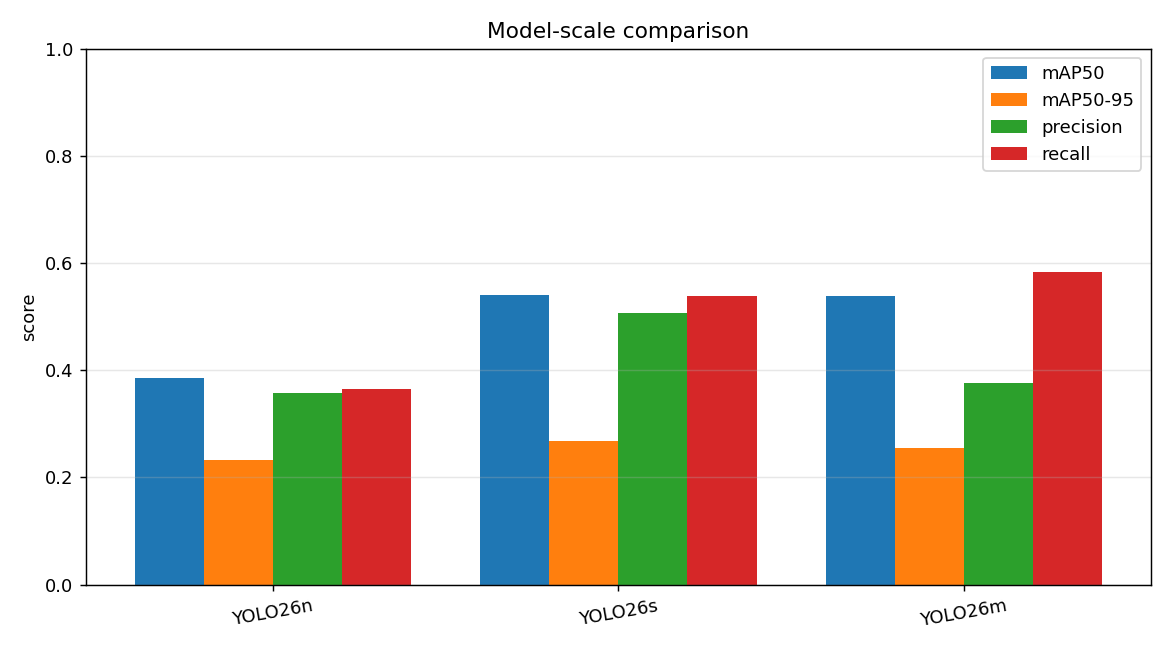

In [18]:
fig = evaluation.plot_model_comparison(comp); fig.savefig(FIG_DIR / 'model_comparison.png', dpi=130); plt.show()
sa = evaluation.speed_accuracy_frame(comp, speeds)
display(sa[['params(M)', 'mAP50', 'mAP50-95', 'speed(ms/img)', 'FPS']])
comp.to_csv(paths['outputs'] / 'model_comparison.csv')

## 7 · Confusion matrix (best model)

Ultralytics writes a confusion matrix during validation; we display the
best model's. Off-diagonal mass between the two linear-crack classes
(`D00`/`D10`) is the expected, and most common, confusion.

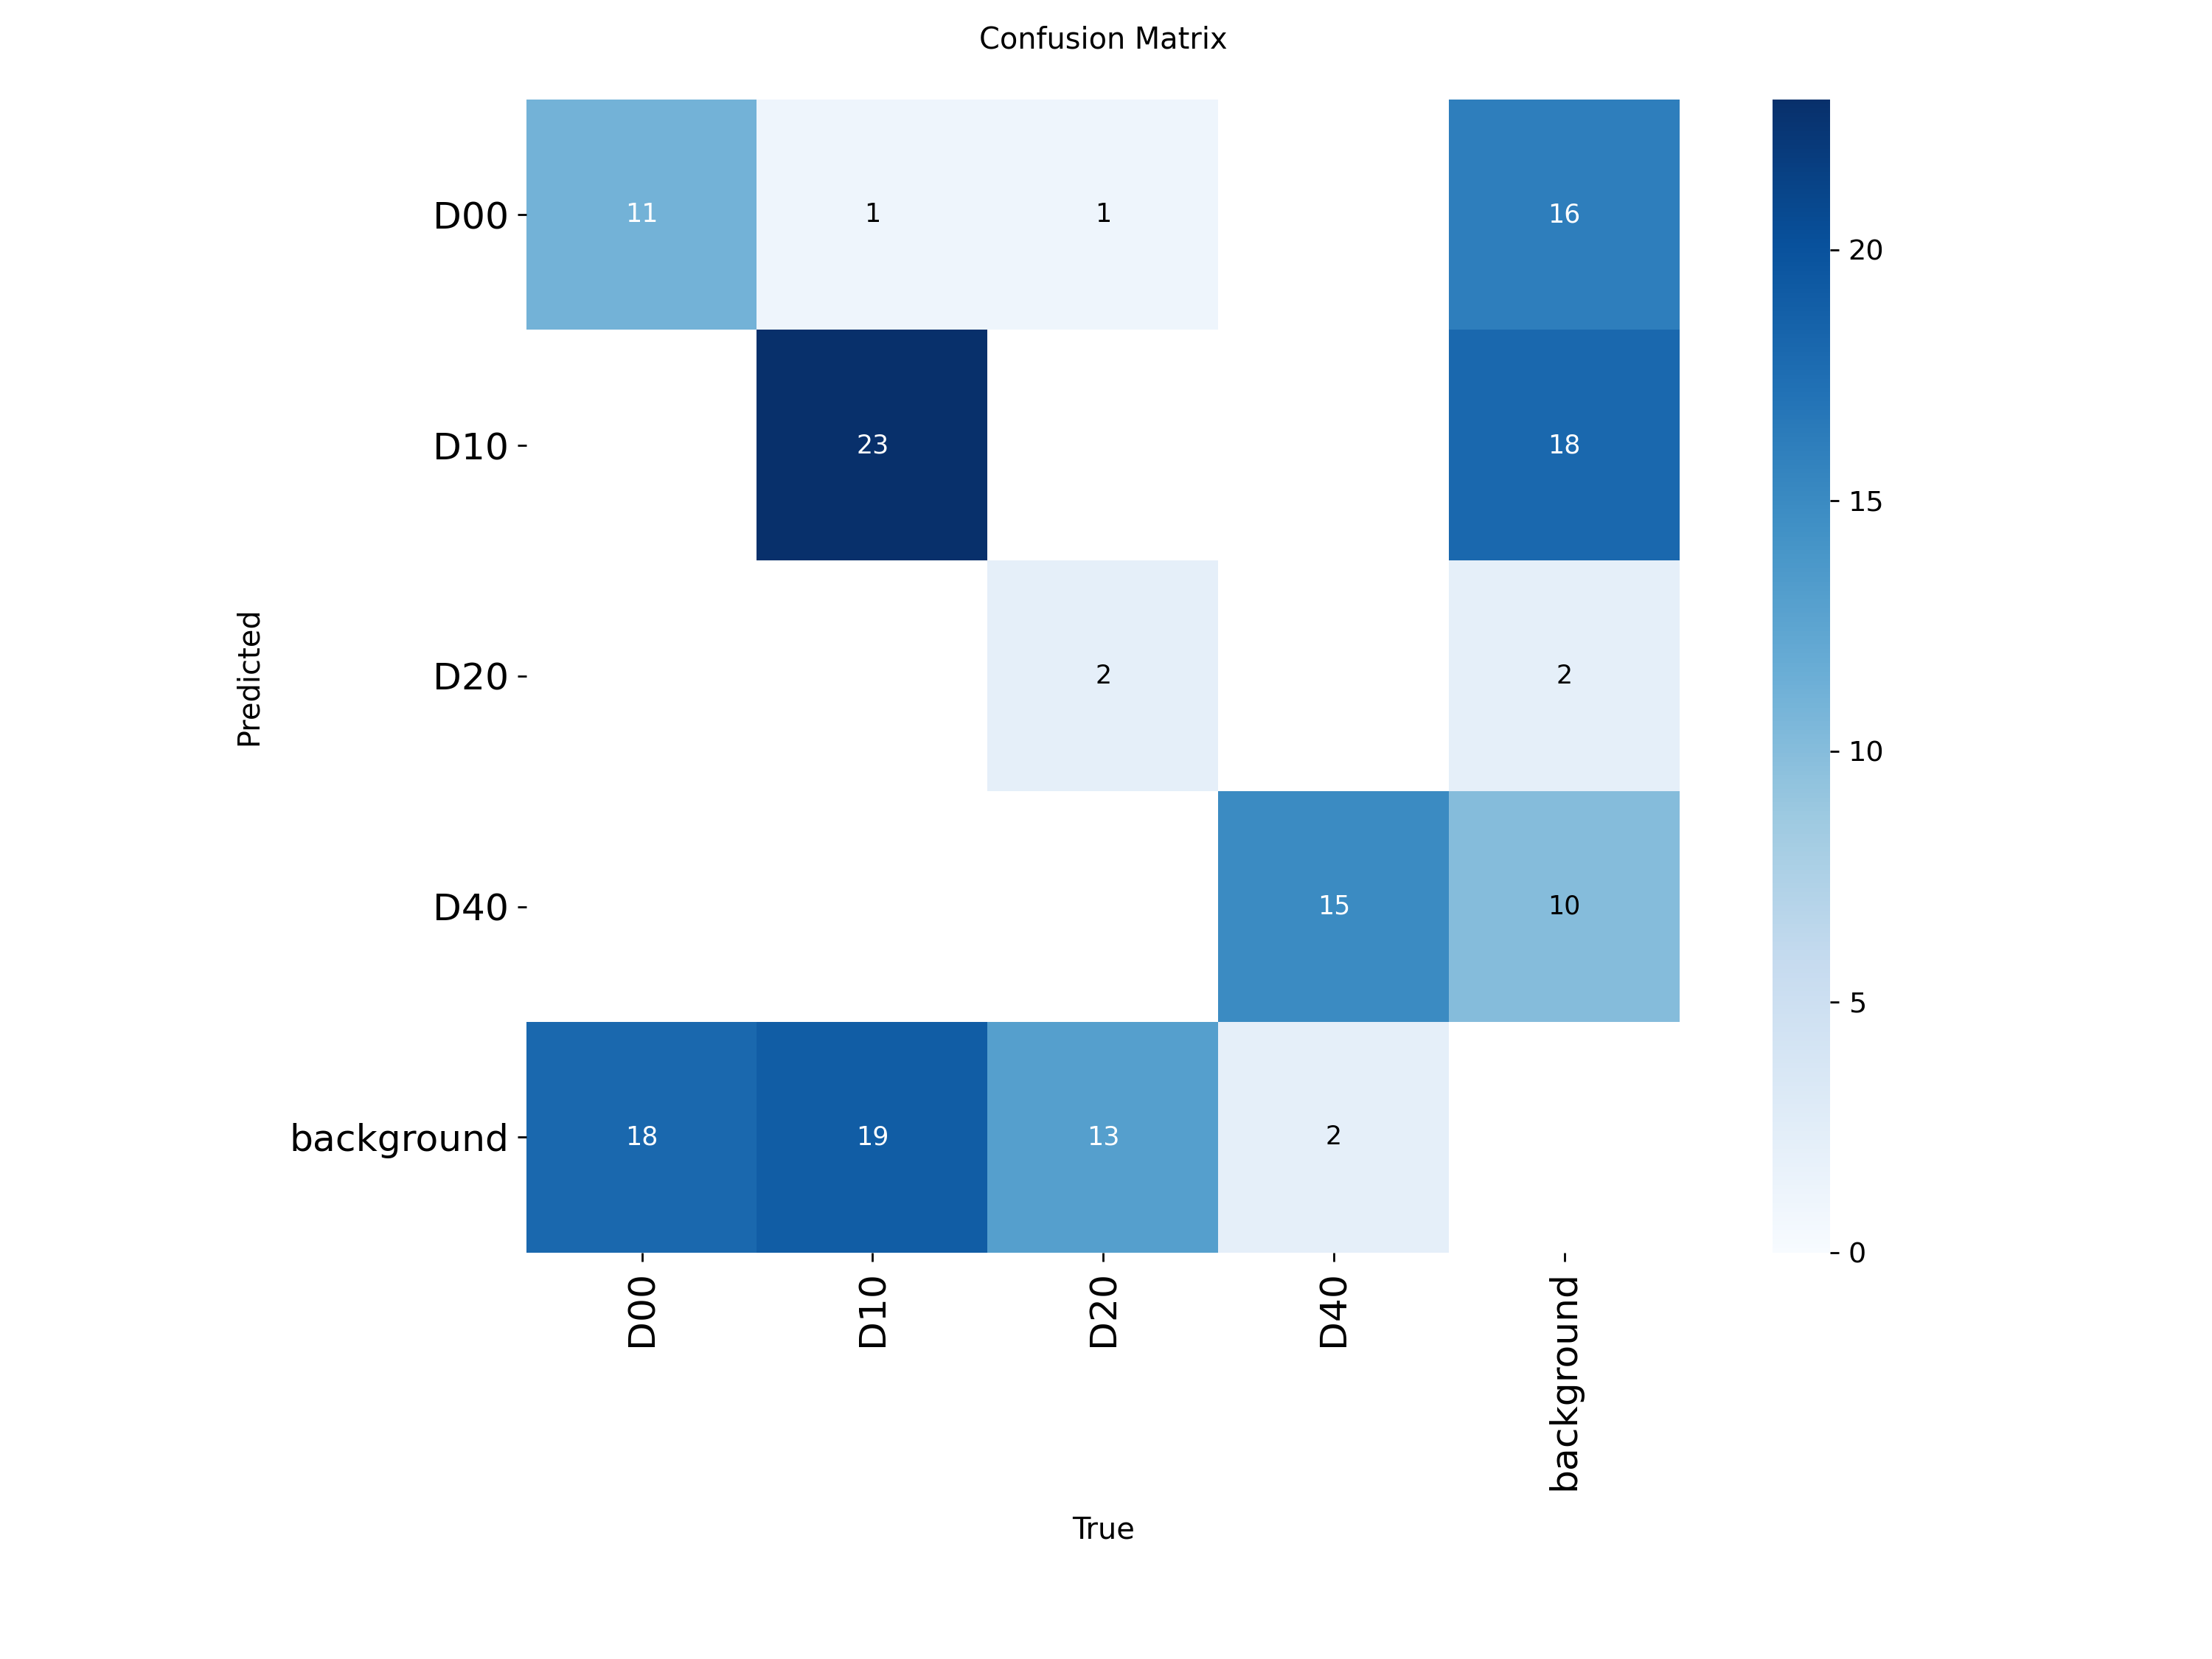

In [19]:
from IPython.display import Image as IPyImage, display as ddisplay
best_scale = best_name.replace('YOLO26', '')
cm = trained[best_scale]['drive_dir'] / 'confusion_matrix.png'
if not cm.exists():
    cm = trained[best_scale]['run_dir'] / 'confusion_matrix.png'
ddisplay(IPyImage(filename=str(cm))) if cm.exists() else print('confusion matrix not found')

## 8 · Select and freeze the best model

We copy the winning `best.pt` to a stable location the inference and demo
notebooks load by default.

In [20]:
final_dir = MODELS_DIR / 'best'; final_dir.mkdir(parents=True, exist_ok=True)
src_best = trained[best_scale]['drive_dir'] / 'weights' / 'best.pt'
shutil.copy2(src_best, final_dir / 'best.pt')
print('Best model:', best_name, '->', final_dir / 'best.pt')

Copied best model to models/best/best.pt


## 9. Results summary and final model choice

**Best model: YOLO26s** (mAP50 about 0.54, mAP50-95 about 0.27, F1 about 0.52), which beats both the smaller nano model and the larger medium model. The medium model overfits this small dataset, so bigger is not better here.

**Per-class story:** potholes are the easiest class (AP50 about 0.87, recall about 1.0) and alligator cracking is the hardest (AP50 about 0.19). The two linear cracks sit in between and are mainly confused with each other.

**Final interpretation:**

1. YOLO26s is the reference model for headline accuracy.
2. YOLO26m is used in the demo when recall is prioritised, because a maintenance triage system should avoid missing defects.
3. Alligator cracking is the main weakness and motivates the future-work proposal for segmentation or more targeted data.
4. A transformer detector such as RF-DETR would be a useful second architecture if more compute were available.
